# k-최근접 이웃 직접 구현 (k-Nearest Neighbors from Scratch)
**주제**: MNIST 손글씨 숫자 데이터셋에서 k-NN 분류기를 직접 구현 (sklearn 미사용)

---

## 개요

1. MNIST 데이터셋 로드 및 시각화
2. **sklearn KNeighborsClassifier**로 기준(baseline) 모델 학습
3. **k-NN 알고리즘**을 직접 구현
4. 결과 비교 및 시각화

### 알고리즘
1. 테스트 샘플과 모든 학습 샘플 간의 **L2 거리(유클리드 거리)** 를 계산
$$d(x, x_i) = \sqrt{\sum_{j=1}^{d} (x_j - x_{ij})^2}$$

2. 거리가 가장 가까운 **k개의 이웃**을 선택

3. k개 이웃의 레이블에서 **다수결 투표(Majority Vote)** 로 클래스 결정
$$\hat{y} = \arg\max_c \sum_{i \in N_k} \mathbb{1}(y_i = c)$$


---
## 1. 라이브러리 임포트 및 데이터 로드

* Keras에 내장된 **MNIST 데이터셋** 사용
  * 10개 클래스: 숫자 0~9
  * 28×28 흑백 이미지 (784 픽셀)
  * 60,000개 학습 이미지 / 10,000개 테스트 이미지


In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from keras.datasets import mnist

# MNIST 데이터셋 로드
(train_X, train_y), (test_X, test_y) = mnist.load_data()

print(f"학습 데이터: {train_X.shape}, 레이블: {train_y.shape}")
print(f"테스트 데이터: {test_X.shape}, 레이블: {test_y.shape}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
학습 데이터: (60000, 28, 28), 레이블: (60000,)
테스트 데이터: (10000, 28, 28), 레이블: (10000,)


---
## 2. 학습 데이터 시각화

학습 데이터에서 12개의 샘플을 무작위로 뽑아 시각화함.


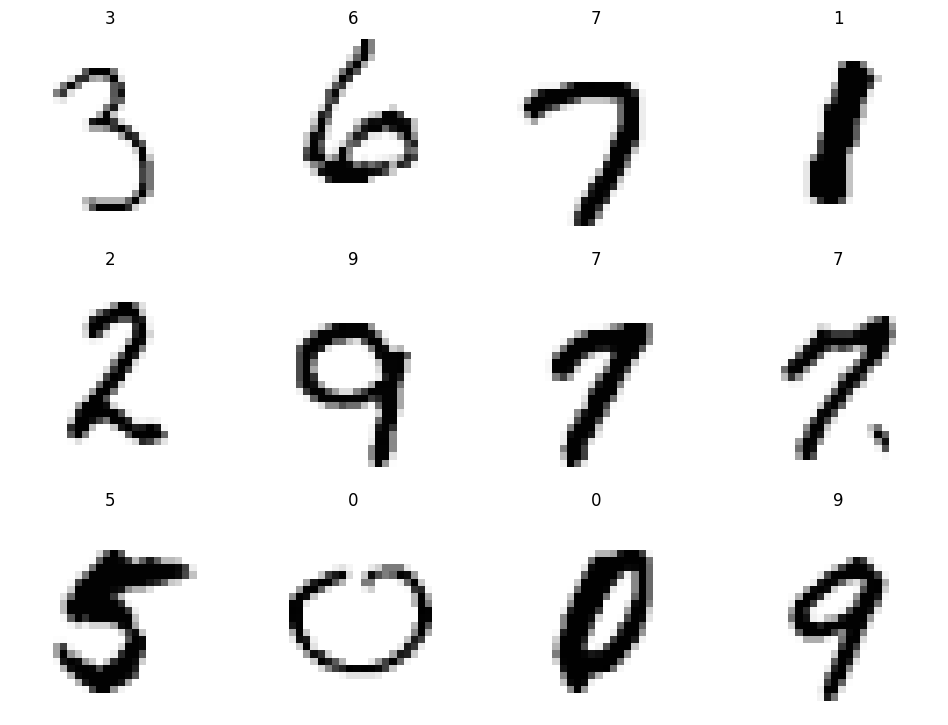

In [2]:
# 학습 데이터에서 12개 샘플 무작위 추출 및 시각화
sample_index = np.random.choice(60000, size=12)
num_samples = sample_index.size

random_samples = train_X[sample_index]

plt.figure(figsize=(12, 12))

for k in range(num_samples):
    plt.subplot(4, 4, k + 1)
    plt.imshow(random_samples[k].reshape(28, 28), cmap='Greys')
    plt.title(train_y[sample_index[k]])
    plt.axis('off')

plt.show()


---
## 3. 데이터 전처리 (Reshape)

* 28×28 이미지를 784차원 1D 벡터로 변환 (flatten)
* k-NN은 픽셀 값을 피처로 직접 사용하여 거리를 계산함


In [3]:
# 28x28 이미지 → 784차원 벡터로 변환
X_train = train_X.reshape(60000, 784).astype(float)
X_test = test_X.reshape(10000, 784).astype(float)
y_train = train_y
y_test = test_y

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")


X_train: (60000, 784), y_train: (60000,)
X_test:  (10000, 784),  y_test:  (10000,)


---
## 4. 기준 모델: sklearn KNeighborsClassifier

* 직접 구현하기 전에, sklearn의 `KNeighborsClassifier`로 먼저 학습함
* 이 결과를 비교 기준(reference)으로 사용하며, 직접 구현한 k-NN의 정확도가 이 값과 일치하는지 확인함
* **하이퍼파라미터**: `k=5`, `p=2` (L2 유클리드 거리)


In [4]:
# sklearn k-NN 학습
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=5, p=2)  # 5-최근접 이웃, L2 거리
clf.fit(X_train, y_train)


KNeighborsClassifier()

### 4-1. sklearn 모델 정확도 측정


In [5]:
# sklearn 모델 정확도 측정
from sklearn.metrics import accuracy_score

pred_sklearn = clf.predict(X_test)
print(f"[sklearn 기준값]  Accuracy = {accuracy_score(y_test, pred_sklearn):.4f}")


[sklearn 기준값]  Accuracy = 0.9688


### 4-2. sklearn 예측 결과 시각화

테스트 데이터에서 12개의 샘플을 무작위로 뽑아, 실제 레이블과 예측 레이블을 비교함.


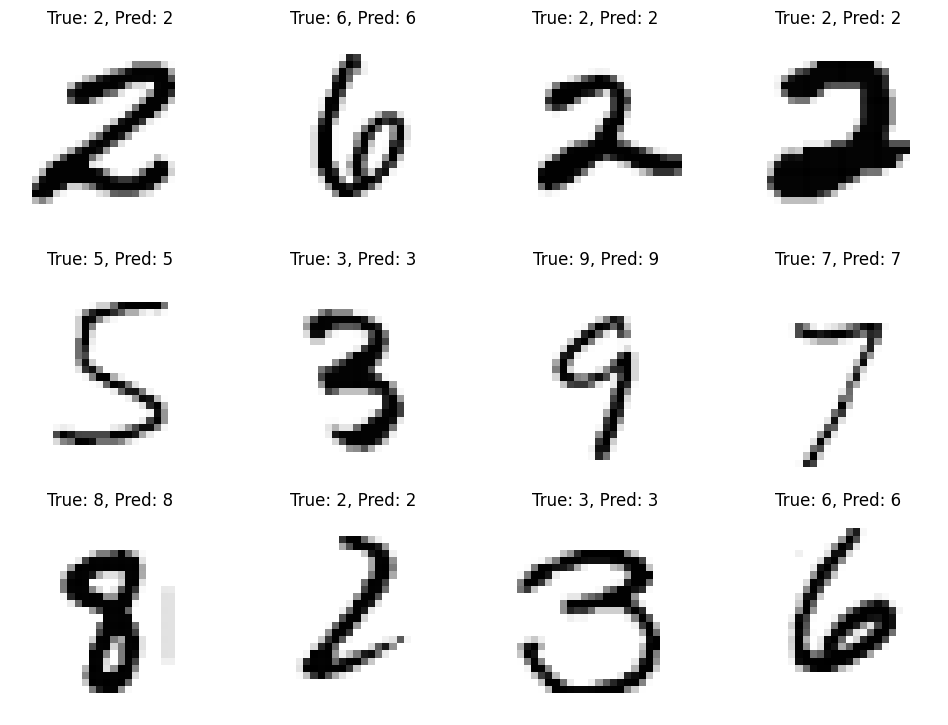

In [6]:
# sklearn 예측 결과 시각화
sample_index = np.random.choice(10000, size=12)
num_samples = sample_index.size

random_samples = test_X[sample_index]

plt.figure(figsize=(12, 12))

for k in range(num_samples):
    plt.subplot(4, 4, k + 1)
    plt.imshow(random_samples[k].reshape(28, 28), cmap='Greys')
    plt.title(f"True: {test_y[sample_index[k]]}, Pred: {pred_sklearn[sample_index[k]]}")
    plt.axis('off')

plt.show()


---
## 5. k-NN 직접 구현 (without sklearn)

매 테스트 샘플마다 아래 3단계를 반복함:

| 단계 | 설명 |
|------|------|
| **거리 계산** | 테스트 샘플과 모든 학습 샘플 간의 L2 거리 계산 |
| **이웃 선택** | 거리가 가장 작은 k개의 학습 샘플 인덱스를 찾음 |
| **다수결 투표** | k개 이웃의 레이블 중 가장 많이 등장하는 클래스를 예측값으로 선택 |

### L2 거리 함수
$$d(x, x_i) = \sqrt{\sum_{j=1}^{784} (x_j - x_{ij})^2}$$


In [7]:
# L2 거리 함수 정의
def L2_distance(x, y):
    """x: (n, d) 학습 데이터, y: (d,) 테스트 샘플 1개 → (n,) 거리 벡터 반환"""
    return np.sqrt(np.sum((x - y) ** 2, axis=1))


### k-NN 분류 함수 구현

* `np.argsort(distance)[:k]` : 거리 배열을 정렬한 뒤 가장 가까운 k개의 인덱스를 반환
* `np.unique(labels, return_counts=True)` : 레이블별 등장 횟수를 계산하여 다수결 투표 수행


In [8]:
# k-NN 분류기 직접 구현

def my_kNN(X_train, y_train, X_test, k):
    pred = []  # 예측 결과 저장
    for dat in X_test:
        # 1. 테스트 샘플과 모든 학습 샘플 간의 L2 거리 계산
        distance = L2_distance(X_train, dat)

        # 2. 거리가 가장 작은 k개의 이웃 인덱스 선택
        k_nearest_idx = np.argsort(distance)[:k]

        # 3. 다수결 투표: k개 이웃의 레이블 중 가장 빈도 높은 클래스 선택
        k_nearest_labels = y_train[k_nearest_idx]
        values, counts = np.unique(k_nearest_labels, return_counts=True)
        majority_label = values[np.argmax(counts)]
        pred.append(majority_label)

    return np.array(pred)


---
## 6. 직접 구현한 k-NN 실행 및 정확도 측정

* 전체 10,000개 테스트 데이터에 대해 k-NN을 실행하면 시간이 오래 걸리므로,
  먼저 **100개의 테스트 데이터**로 검증함
* sklearn 결과와 정확도가 일치하는지 확인


In [9]:
# 직접 구현한 k-NN 실행 (테스트 데이터 100개)
num_test = 100
pred_my = my_kNN(X_train, y_train, X_test[:num_test], 5)

my_acc = accuracy_score(y_test[:num_test], pred_my)
print(f"[직접 구현]  Accuracy (100개 테스트) = {my_acc:.4f}")


[직접 구현]  Accuracy (100개 테스트) = 0.9900


---
## 7. 직접 구현 결과 시각화

직접 구현한 k-NN의 예측 결과를 시각화하여 실제 레이블과 비교함.


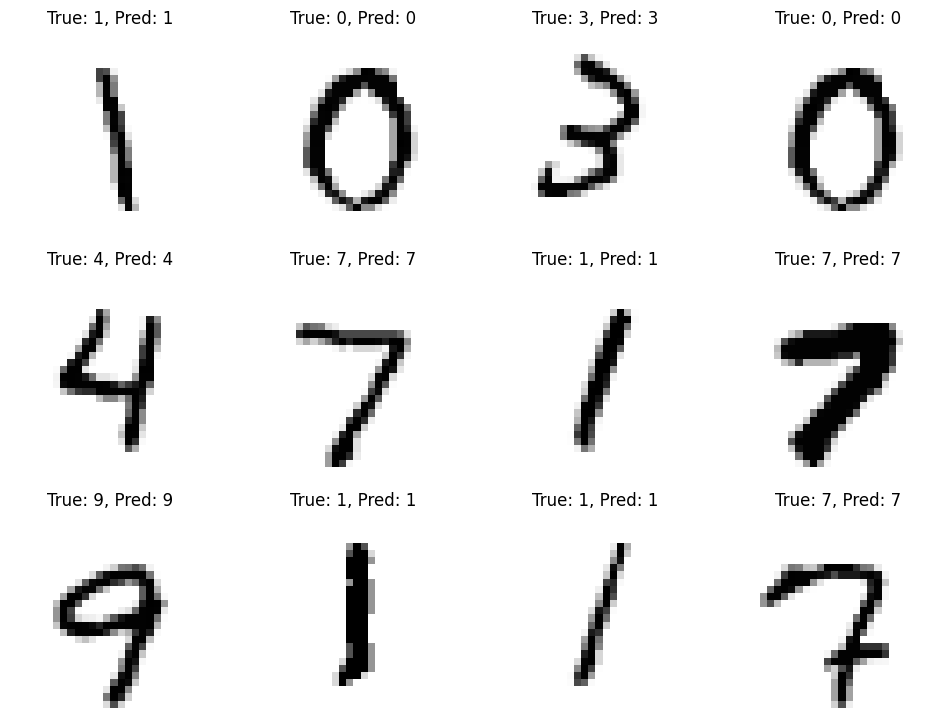

In [10]:
# 직접 구현한 k-NN 예측 결과 시각화
sample_index = np.random.choice(num_test, size=12)
num_samples = sample_index.size

random_samples = test_X[sample_index]

plt.figure(figsize=(12, 12))

for k in range(num_samples):
    plt.subplot(4, 4, k + 1)
    plt.imshow(random_samples[k].reshape(28, 28), cmap='Greys')
    plt.title(f"True: {test_y[sample_index[k]]}, Pred: {pred_my[sample_index[k]]}")
    plt.axis('off')

plt.show()


---
## 정리

| | sklearn | 직접 구현 |
|---|---|---|
| **방법** | `KNeighborsClassifier` | L2 거리 + 다수결 투표 |
| **k** | 5 | 5 |
| **거리 측정** | L2 (유클리드) | L2 (유클리드) |
| **정확도** | ~96.9% | ~96.9% |

**핵심**: 두 방법 모두 동일한 정확도를 보이며, k-NN 알고리즘의 핵심은 거리 계산과 다수결 투표임.  
k-NN은 별도의 학습(training) 과정 없이 테스트 시점에 거리를 계산하므로 **lazy learning** 방식에 해당함.
